In [1]:
import torch
from gsnn.models.GSNN import GSNN
from gsnn.interpret.GSNNExplainer import GSNNExplainer
from gsnn.interpret.ContrastiveIGExplainer import ContrastiveIGExplainer
import pandas as pd
import numpy as np
import networkx as nx
from matplotlib import pyplot as plt
from gsnn_mds.data.AMLDataset import AMLDataset

from gsnn.interpret.CounterfactualExplainer import CounterfactualExplainer 
from gsnn.interpret.ContrastiveOcclusionExplainer import ContrastiveOcclusionExplainer
from gsnn.interpret.utils import plot_edge_importance
from gsnn.interpret.NoiseTunnel import NoiseTunnel 

import seaborn as sbn 
from pypath.utils import mapping

%load_ext autoreload
%autoreload 2 


In [2]:
def create_input_mapping(inputs_df, data):
    """Create mapping from patient IDs to input vectors.
    
    Note: inputs_df is ordered identically to data.node_names_dict['input']
    and can be directly converted into the input tensor.
    """
    print("Creating input mapping...")
    
    id2x = {}
    
    # Verify that inputs_df columns match the input node names
    input_nodes = data.node_names_dict['input']
    
    # Reorder inputs_df columns to match the order of input nodes
    inputs_df_ordered = inputs_df[input_nodes]
    
    # Convert each row to input tensor directly
    for sample_id, row in inputs_df_ordered.iterrows():
        x = torch.tensor(row.values.astype(np.float32), dtype=torch.float32)
        id2x[sample_id] = x
    
    print(f"Created input mapping for {len(id2x)} patients")
    return id2x

In [3]:
model = torch.load('../../workflow_outputs/gsnn-mds/exp/default/gsnn/gsnn_model.pt', weights_only=False)

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.eval() 
model = model.to(device) 

batch_size = 256


In [5]:
data = torch.load('../../workflow_outputs/gsnn-mds/exp/default/graph/graph.pt', weights_only=False)

inputs_df = pd.read_csv('../../workflow_outputs/gsnn-mds/exp/default/graph/inputs.csv')
inputs_df = inputs_df[lambda x: x.id.str.startswith('M')] # MLL-XXX or MUC-xxx

id2x = create_input_mapping(inputs_df.set_index('id'), data)
ids = list(id2x.keys()) 

drug_inputs = [x.split('__')[1] for x in data.node_names_dict['input'] if x.split('__')[0] == 'DRUG']


Creating input mapping...
Created input mapping for 668 patients


In [6]:
inhibitor = ['selumetinib (azd6244)', 'trametinib (gsk1120212)', 'ci-1040 (pd184352)']
response = 0 

synth_drug = pd.DataFrame({'id': ids*len(inhibitor), 'partition': 'infer', 'response': response, 'inhibitor_1': inhibitor*len(ids)})

#synth_drug = synth_drug.assign(inhibitor_2 = [x.split(' + ')[1] for x in inhibitor*len(ids)])
synth_drug = synth_drug.assign(inhibitor_2 = None) 

synth_drug.head() 

,id,partition,response,inhibitor_1,inhibitor_2
0,MLL_00003,infer,0,selumetinib (azd6244),None
1,MLL_00009,infer,0,trametinib (gsk1120212),None
2,MLL_09939,infer,0,ci-1040 (pd184352),None
3,MLL_09941,infer,0,selumetinib (azd6244),None
4,MLL_09942,infer,0,trametinib (gsk1120212),None


In [7]:
mds_muts = pd.read_excel('../../data/805_data_20250107.xlsx') 

mds_ids_with_stag_mut = mds_muts[mds_muts.STAG2 == 'POSITIVE']['MLL ID'].unique()  
mds_ids_with_kras_mut = mds_muts[mds_muts.KRAS == 'POSITIVE']['MLL ID'].unique()

synth_drug = synth_drug.assign(stag_mut = [1 if x in mds_ids_with_stag_mut else 0 for x in synth_drug.id])
synth_drug = synth_drug.assign(kras_mut = [1 if x in mds_ids_with_kras_mut else 0 for x in synth_drug.id])
synth_drug.head() 


,id,partition,response,inhibitor_1,inhibitor_2,stag_mut,kras_mut
0,MLL_00003,infer,0,selumetinib (azd6244),None,0,0
1,MLL_00009,infer,0,trametinib (gsk1120212),None,0,0
2,MLL_09939,infer,0,ci-1040 (pd184352),None,0,0
3,MLL_09941,infer,0,selumetinib (azd6244),None,0,0
4,MLL_09942,infer,0,trametinib (gsk1120212),None,0,0


In [8]:
pred_dataset = AMLDataset(id2x, synth_drug, data.node_names_dict['input'])
pred_loader = torch.utils.data.DataLoader(pred_dataset, batch_size=256, shuffle=False) 

print(f'Number of predictions: {len(pred_dataset)}')

Number of predictions: 2004


In [9]:
yhat = [] 
xs = [] 

with torch.no_grad(): 
    for x, _ in pred_loader:
        xs.append(x.cpu()) 
        x = x.to(device) 
        yhat.append(model(x).cpu()) 

yhat = torch.cat(yhat, axis=0) 
xs = torch.cat(xs, axis=0) 

yhat = yhat.reshape(-1) 

synth_drug = synth_drug.assign(yhat = yhat) 
synth_drug.head() 

,id,partition,response,inhibitor_1,inhibitor_2,stag_mut,kras_mut,yhat
0,MLL_00003,infer,0,selumetinib (azd6244),None,0,0,0.419919
1,MLL_00009,infer,0,trametinib (gsk1120212),None,0,0,-0.808475
2,MLL_09939,infer,0,ci-1040 (pd184352),None,0,0,0.160392
3,MLL_09941,infer,0,selumetinib (azd6244),None,0,0,0.447704
4,MLL_09942,infer,0,trametinib (gsk1120212),None,0,0,-0.648377


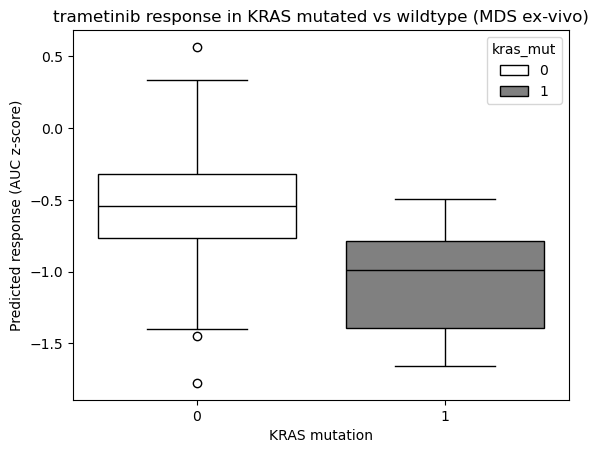

In [10]:
# make black and white (no fill)
sbn.boxplot(x='kras_mut', y='yhat', data=synth_drug[lambda x: x.inhibitor_1 == 'trametinib (gsk1120212)'], hue='kras_mut', palette={0: 'white', 1: 'gray'}, linewidth=1, linecolor='k') 
plt.xlabel('KRAS mutation') 
plt.ylabel('Predicted response (AUC z-score)') 
plt.title('trametinib response in KRAS mutated vs wildtype (MDS ex-vivo)')
plt.show() 



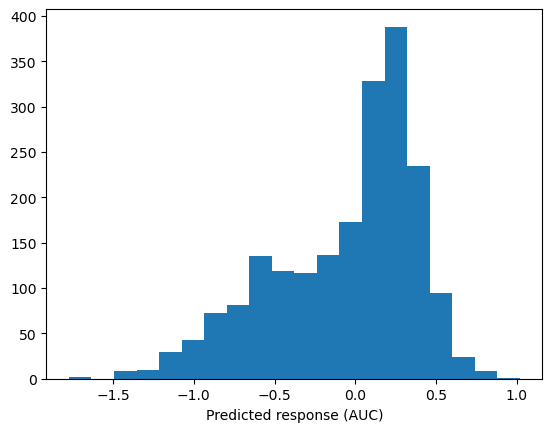

In [11]:
plt.figure() 
plt.hist(synth_drug.yhat, bins=20) 
plt.xlabel('Predicted response (AUC)') 
plt.show() 

In [12]:
xpl_drug = 'trametinib (gsk1120212)'

NN = 250
scores = []
for i in range(NN): 
    y_res_ix = synth_drug[lambda x: (x.inhibitor_1 == xpl_drug) & (x.kras_mut == 0)].sample(1).index.values[0]
    y_sens_ix = synth_drug[lambda x: (x.inhibitor_1 == xpl_drug) & (x.kras_mut == 1)].sample(1).index.values[0] 

    x_res = xs[y_res_ix]
    x_sens = xs[y_sens_ix] 

    torch.cuda.empty_cache() 

    explainer = ContrastiveIGExplainer(model, data, n_steps=100)
    ig_res = explainer.explain(x_res, x_sens, target_idx=0)
    ig_res = ig_res.rename(columns={'score': f'score_{i}'})

    scores.append(ig_res.set_index(['source', 'target'])) 

ig_res = pd.concat(scores, axis=1, ignore_index=False)

ig_res = ig_res.assign(score = ig_res[[f'score_{i}' for i in range(NN)]].mean(axis=1)).reset_index()
ig_res = ig_res.assign(prob_score_pos = (ig_res[[f'score_{i}' for i in range(NN)]].values > 0).astype(float).mean(axis=1))
ig_res = ig_res.assign(prob_score_neg = (ig_res[[f'score_{i}' for i in range(NN)]].values < 0).astype(float).mean(axis=1))
ig_res = ig_res.assign(prob_either = np.maximum(ig_res.prob_score_pos, ig_res.prob_score_neg))

ig_res = ig_res[['source', 'target', 'score', 'prob_score_pos', 'prob_score_neg', 'prob_either']]

ig_res = ig_res.assign(source_type = ig_res.source.str.split('__').str[0])
ig_res = ig_res.assign(target_type = ig_res.target.str.split('__').str[0]) 
ig_res = ig_res.assign(source_name = ig_res.source.str.split('__').str[1]) 
ig_res = ig_res.assign(target_name = ig_res.target.str.split('__').str[1]) 


# map uni  to genesymbol 

uniprots = set(ig_res[lambda x: x.source_type.isin(['PROTEIN', 'RNA'])].source_name.unique().tolist() + \
                ig_res[lambda x: x.target_type.isin(['PROTEIN', 'RNA'])].target_name.unique().tolist() )
print(len(uniprots))

uni2symb = {}
for ii, uniprot in enumerate(uniprots): 
    print(f'progress: {ii}/{len(uniprots)}', end='\r')
    symb = mapping.map_name(uniprot, id_type='uniprot', target_id_type='genesymbol')
    if len(symb) > 0: 
        uni2symb[uniprot] = symb.pop()

ig_res = ig_res.assign(source_symb = ig_res.source_name.map(uni2symb))
ig_res = ig_res.assign(target_symb = ig_res.target_name.map(uni2symb))

## 

ig_res.head() 

6001


,source,target,score,prob_score_pos,prob_score_neg,prob_either,source_type,target_type,source_name,target_name,source_symb,target_symb
0,PROTEIN__Q7Z3Y8,PATHWAY__Keratinization,-0.000031,0.436,0.564,0.564,PROTEIN,PATHWAY,Q7Z3Y8,Keratinization,KRT27,NaN
1,PROTEIN__Q7Z3Y8,PATHWAY__Formation of the cornified envelope,-0.000005,0.468,0.532,0.532,PROTEIN,PATHWAY,Q7Z3Y8,Formation of the cornified envelope,KRT27,NaN
2,PROTEIN__O43306,PROTEIN__P49913,-0.000011,0.436,0.564,0.564,PROTEIN,PROTEIN,O43306,P49913,ADCY6,CAMP
3,PROTEIN__O43306,PROTEIN__P22694,0.000023,0.548,0.452,0.548,PROTEIN,PROTEIN,O43306,P22694,ADCY6,PRKACB
4,PROTEIN__O43306,PROTEIN__P51817,0.000038,0.620,0.380,0.620,PROTEIN,PROTEIN,O43306,P51817,ADCY6,PRKX


In [13]:
ig_res[lambda x: x.source.str.contains('PATHWAY__')].sort_values('prob_either', ascending=False).head(10).style.hide()

source,target,score,prob_score_pos,prob_score_neg,prob_either,source_type,target_type,source_name,target_name,source_symb,target_symb
PATHWAY__Constitutive Signaling by AKT1 E17K in Cancer,OUT_AUC,0.001929,0.892000,0.108000,0.892000,PATHWAY,OUT_AUC,Constitutive Signaling by AKT1 E17K in Cancer,nan,nan,nan
PATHWAY__RAF/MAP kinase cascade,OUT_AUC,0.001706,0.860000,0.140000,0.860000,PATHWAY,OUT_AUC,RAF/MAP kinase cascade,nan,nan,nan
PATHWAY__RAF activation,PATHWAY__RAF activation,0.001380,0.836000,0.164000,0.836000,PATHWAY,PATHWAY,RAF activation,RAF activation,nan,nan
PATHWAY__Role of LAT2/NTAL/LAB on calcium mobilization,OUT_AUC,0.001604,0.836000,0.164000,0.836000,PATHWAY,OUT_AUC,Role of LAT2/NTAL/LAB on calcium mobilization,nan,nan,nan
PATHWAY__PIP3 activates AKT signaling,OUT_AUC,0.001132,0.824000,0.176000,0.824000,PATHWAY,OUT_AUC,PIP3 activates AKT signaling,nan,nan,nan
PATHWAY__RAF activation,OUT_AUC,0.002473,0.820000,0.180000,0.820000,PATHWAY,OUT_AUC,RAF activation,nan,nan,nan
PATHWAY__PI3K Cascade,OUT_AUC,0.000803,0.816000,0.184000,0.816000,PATHWAY,OUT_AUC,PI3K Cascade,nan,nan,nan
PATHWAY__Negative regulation of MAPK pathway,OUT_AUC,0.000926,0.800000,0.200000,0.800000,PATHWAY,OUT_AUC,Negative regulation of MAPK pathway,nan,nan,nan
PATHWAY__CD28 dependent PI3K/Akt signaling,PATHWAY__CD28 dependent PI3K/Akt signaling,0.000523,0.800000,0.200000,0.800000,PATHWAY,PATHWAY,CD28 dependent PI3K/Akt signaling,CD28 dependent PI3K/Akt signaling,nan,nan
PATHWAY__Paradoxical activation of RAF signaling by kinase inactive BRAF,OUT_AUC,0.001449,0.792000,0.208000,0.792000,PATHWAY,OUT_AUC,Paradoxical activation of RAF signaling by kinase inactive BRAF,nan,nan,nan


In [14]:
ig_res.sort_values('score', ascending=False)[lambda x: x.source.str.contains('EXPR__')].head(5).style.hide()

source,target,score,prob_score_pos,prob_score_neg,prob_either,source_type,target_type,source_name,target_name,source_symb,target_symb
EXPR__Q02750,PROTEIN__Q02750,0.005035,0.600000,0.400000,0.600000,EXPR,PROTEIN,Q02750,Q02750,MAP2K1,MAP2K1
EXPR__P07948,PROTEIN__P07948,0.002797,0.608000,0.392000,0.608000,EXPR,PROTEIN,P07948,P07948,LYN,LYN
EXPR__P01911,PROTEIN__P01911,0.002561,0.712000,0.288000,0.712000,EXPR,PROTEIN,P01911,P01911,HLA-DRB1,HLA-DRB1
EXPR__P17655,PROTEIN__P17655,0.002440,0.796000,0.204000,0.796000,EXPR,PROTEIN,P17655,P17655,CAPN2,CAPN2
EXPR__Q9Y5Q3,PROTEIN__Q9Y5Q3,0.002321,0.716000,0.284000,0.716000,EXPR,PROTEIN,Q9Y5Q3,Q9Y5Q3,MAFB,MAFB


In [15]:
ig_res.sort_values('score', ascending=False)[lambda x: x.source.str.contains('MUT__')].head(5).style.hide()


source,target,score,prob_score_pos,prob_score_neg,prob_either,source_type,target_type,source_name,target_name,source_symb,target_symb
MUT__P01116,PROTEIN__P01116,0.012628,0.856000,0.144000,0.856000,MUT,PROTEIN,P01116,P01116,KRAS,KRAS
MUT__P21359,PROTEIN__P21359,0.001455,0.596000,0.404000,0.596000,MUT,PROTEIN,P21359,P21359,NF1,NF1
MUT__P01111,PROTEIN__P01111,0.000951,0.740000,0.260000,0.740000,MUT,PROTEIN,P01111,P01111,NRAS,NRAS
MUT__P04637,PROTEIN__P04637,0.000697,0.516000,0.484000,0.516000,MUT,PROTEIN,P04637,P04637,TP53,TP53
MUT__Q06124,PROTEIN__Q06124,0.000186,0.660000,0.340000,0.660000,MUT,PROTEIN,Q06124,Q06124,PTPN11,PTPN11


/home/teddy/miniconda3/envs/gsnn-mds/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/teddy/miniconda3/envs/gsnn-mds/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


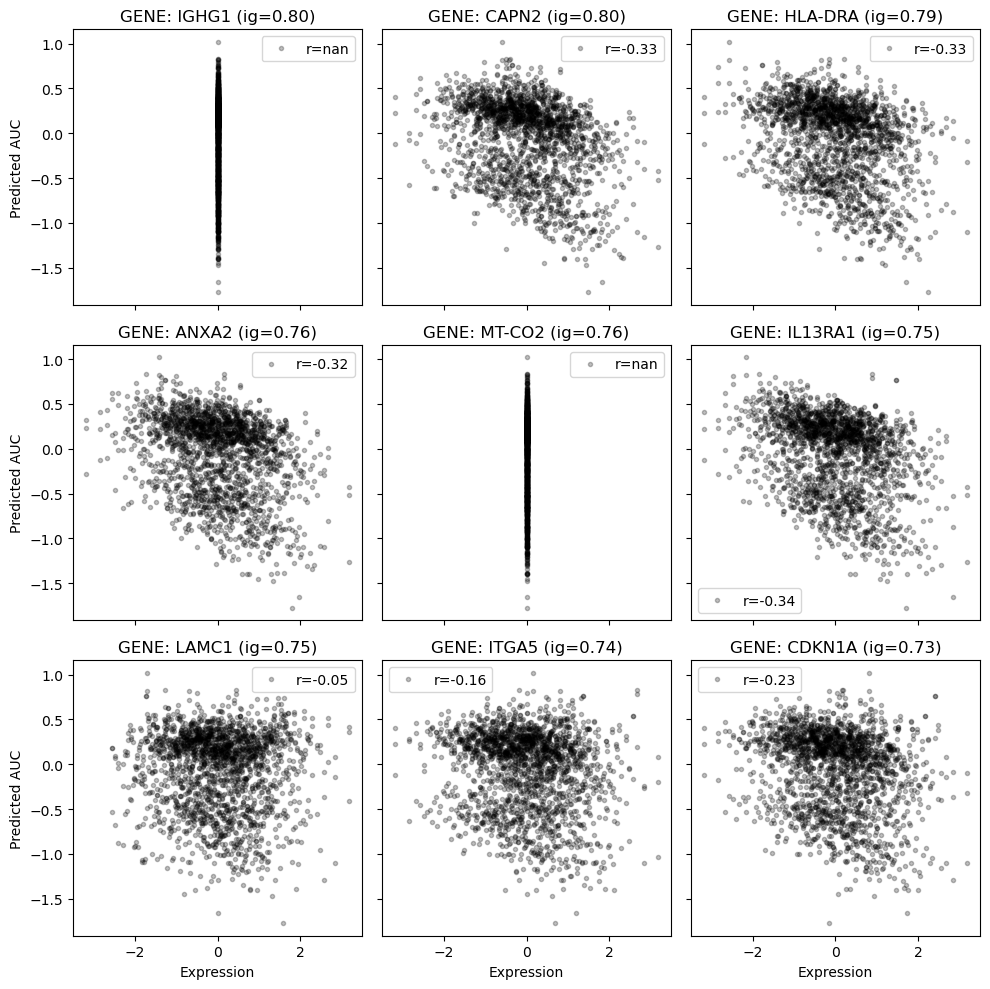

In [16]:
biomarker_candidates = ig_res.sort_values('prob_either', ascending=False)[lambda x: x.source.str.contains('EXPR__')].head(9)

f, axes = plt.subplots(3, 3, figsize=(10, 10), sharex=True, sharey=True) 

for i, (ax, (j,row)) in enumerate(zip(axes.flatten(), biomarker_candidates.iterrows())): 
    uniprot = row.source.split('__')[1]

    try: 
        name = uni2symb[uniprot]
    except: 
        name = uniprot

    r = np.corrcoef(xs[:, data.node_names_dict['input'].index(row.source)].detach().cpu().numpy(), synth_drug.yhat.values)[0,1]
    ax.plot(xs[:, data.node_names_dict['input'].index(row.source)].detach().cpu().numpy(), synth_drug.yhat.values, 'k.', alpha=0.25, label=f'r={r:.2f}') 
    ax.set_title(f'GENE: {name} (ig={row.prob_either:.2f})') 
    ax.legend() 
    #tmp = synth_drug.copy().assign(expr=xs[:, data.node_names_dict['input'].index(row.source)].detach().cpu().numpy())
    #sbn.regplot(x='expr', y='yhat', data=tmp, ax=ax, scatter=False, color='r', label=None, ) 

axes[0,0].set_ylabel('Predicted AUC') 
axes[1,0].set_ylabel('Predicted AUC')
axes[2,0].set_ylabel('Predicted AUC')
axes[2,0].set_xlabel('Expression') 
axes[2,1].set_xlabel('Expression') 
axes[2,2].set_xlabel('Expression') 

plt.tight_layout() 
plt.show() 

In [45]:
ig_res[lambda x: x.source.str.contains('MUT')].sort_values('score', ascending=False).head(5)

,source,target,score,prob_score_pos,prob_score_neg,prob_either,source_type,target_type,source_name,target_name,source_symb,target_symb
99710,MUT__P01116,PROTEIN__P01116,0.012628,0.856,0.144,0.856,MUT,PROTEIN,P01116,P01116,KRAS,KRAS
99687,MUT__P21359,PROTEIN__P21359,0.001455,0.596,0.404,0.596,MUT,PROTEIN,P21359,P21359,NF1,NF1
99688,MUT__P01111,PROTEIN__P01111,0.000951,0.740,0.260,0.740,MUT,PROTEIN,P01111,P01111,NRAS,NRAS
99689,MUT__P04637,PROTEIN__P04637,0.000697,0.516,0.484,0.516,MUT,PROTEIN,P04637,P04637,TP53,TP53
99704,MUT__Q06124,PROTEIN__Q06124,0.000186,0.660,0.340,0.660,MUT,PROTEIN,Q06124,Q06124,PTPN11,PTPN11


In [39]:
ig_res[lambda x: x.source == 'PATHWAY__Signaling downstream of RAS mutants'].sort_values('score', ascending=False).head(5)

,source,target,score,prob_score_pos,prob_score_neg,prob_either,source_type,target_type,source_name,target_name,source_symb,target_symb
100087,PATHWAY__Signaling downstream of RAS mutants,OUT_AUC,0.001784,0.700,0.300,0.700,PATHWAY,OUT_AUC,Signaling downstream of RAS mutants,NaN,NaN,NaN
106874,PATHWAY__Signaling downstream of RAS mutants,PATHWAY__Signaling downstream of RAS mutants,0.000152,0.548,0.452,0.548,PATHWAY,PATHWAY,Signaling downstream of RAS mutants,Signaling downstream of RAS mutants,NaN,NaN


In [41]:
t = ig_res.sort_values('prob_score_pos', ascending=False).prob_score_pos.values[450]
print(t)
ig_res2 =  ig_res[lambda x: (x.prob_score_pos >= t) | (x.source.str.contains('DRUG__'))] #| (x.target.str.contains('OUT_AUC'))] 

#ig_res2 = ig_res2.assign(source = [f'{x.source_type}__{x.source_symb}' if x.source_type in ['PROTEIN', 'RNA'] else x.source for x in ig_res2.itertuples()])
#ig_res2 = ig_res2.assign(target = [f'{x.target_type}__{x.target_symb}' if x.target_type in ['PROTEIN', 'RNA'] else x.target for x in ig_res2.itertuples()])

ig_res2 = ig_res2.assign(source = [f'{x.source_symb}' if x.source_type in ['PROTEIN', 'RNA'] else x.source for x in ig_res2.itertuples()])
ig_res2 = ig_res2.assign(target = [f'{x.target_symb}' if x.target_type in ['PROTEIN', 'RNA'] else x.target for x in ig_res2.itertuples()])

#ig_res2 = ig_res2.assign(score = ig_res2.prob_either * np.sign(ig_res2.prob_score_pos - ig_res2.prob_score_neg))
ig_res2 = ig_res2.assign(score = ig_res2.prob_score_pos)
ig_res2 = ig_res2[['source', 'target', 'score']]
ig_res2.head() 

0.796


,source,target,score
407,MED14,PATHWAY__Transcriptional regulation of white a...,0.816
522,PTGS1,PIK3CG,0.820
1881,ARAF,SF3B1,0.804
2172,FGF4,PATHWAY__PIP3 activates AKT signaling,0.800
2336,FGFR4,MDFI,0.860


In [44]:
ig_res2[lambda x: x.source.str.contains('MUT')]

,source,target,score
99710,MUT__P01116,KRAS,0.856


In [43]:
plot_edge_importance(ig_res2, figsize=(12,12), leafs=['OUT_AUC'], roots=[f'DRUG__{xpl_drug}', 'MUT__P01116'], interactive=True, )

✅ ipycytoscape imported successfully
🔧 Position bounds: x(27, 823), y(18, 666)
🔧 Scale factor: 0.617
📊 Graph created: 27 nodes, 50 edges
🔧 Position bounds: x(27, 823), y(18, 666)
🔧 Scale factor: 0.617

🎨 Edge Color Legend (Score Range: 0.776 to 0.892):
   Continuous color mapping from -1.0 to +1.0:
   🔵 -1.0: Dark Blue (#0066cc)
   ⚪  0.0: White (#ffffff)
   🔴 +1.0: Dark Red (#cc0000)
   Colors interpolate smoothly between these values

🎉 Interactive Cytoscape Graph with Draggable Nodes!
✅ Drag nodes to rearrange them
✅ Zoom with mouse wheel
✅ Pan by dragging background
✅ Hover over edges to see importance scores


CytoscapeWidget(cytoscape_layout={'name': 'preset'}, cytoscape_style=[{'selector': 'node', 'style': {'content'…

✅ Widget displayed successfully


CytoscapeWidget(cytoscape_layout={'name': 'preset'}, cytoscape_style=[{'selector': 'node', 'style': {'content'…

In [ ]:
# TODO: include cell type like gene sets (?)
# MUT only graph vs EXPR only graph 
# can we improve ven preds 


# Counterfactual explanations 

In [51]:
cf_explainer = CounterfactualExplainer(model, data) 

# we will only optimize non-drug inputs to look for sensitivity predictors 
trainable_mask = torch.tensor(['DRUG__' not in x for x in data.node_names_dict['input']], dtype=torch.bool)

res = cf_explainer.explain(x_res.view(1, -1), target_idx=0, target_value=-0.5, trainable_mask=trainable_mask, 
                            lr=1e-2, dropout=0.25, weight_decay=1e-1)

print(res.attrs)
 
res.sort_values('perturbation', ascending=False)

{'converged_loss': 0.28574684262275696, 'iterations': 1000, 'batch_size': 1, 'original_prediction': array([[0.763871]], dtype=float32), 'final_prediction': array([[-0.12094212]], dtype=float32), 'target_value': array([[-0.5]], dtype=float32)}


,feature,original,perturbation,counterfactual
1618,MUT__P01116,0.000000,1.146089,1.146089
1599,MUT__P01111,0.000000,0.691040,0.691040
720,EXPR__P05771,-1.925453,0.417030,-1.508422
684,EXPR__Q13153,-2.681895,0.354663,-2.327232
1442,EXPR__Q96GD4,-2.406518,0.303355,-2.103163
...,...,...,...,...
950,EXPR__P18754,-3.181701,-0.248761,-3.430462
1046,EXPR__P04637,-2.243103,-0.253484,-2.496587
406,EXPR__P27986,0.800997,-0.268745,0.532252
1487,EXPR__Q9HCE7,2.567317,-0.308071,2.259246


In [53]:
res.sort_values('perturbation', ascending=False).head(10).style.hide()

feature,original,perturbation,counterfactual
MUT__P01116,0.000000,1.146089,1.146089
MUT__P01111,0.000000,0.691040,0.691040
EXPR__P05771,-1.925453,0.417030,-1.508422
EXPR__Q13153,-2.681895,0.354663,-2.327232
EXPR__Q96GD4,-2.406518,0.303355,-2.103163
EXPR__Q02750,1.654152,0.290688,1.944841
EXPR__P63165,-1.859491,0.285372,-1.574120
EXPR__P06400,-0.732065,0.271510,-0.460555
MUT__P19544,0.000000,0.264001,0.264001
EXPR__P01589,2.848514,0.214838,3.063352


In [78]:
res.perturbation.abs().sum() 

np.float32(67.89554)

In [20]:
torch.cuda.empty_cache() 

# Try a slightly different approach... 

for the top N most resistant patients, can we find an counterfactual example that increases sensitivity? 

In [85]:
x_res_batch = xs[synth_drug[lambda x: (x.inhibitor_1 == xpl_drug) & (x.stag_mut == 1)].sample(30).index.values]
print(x_res_batch.shape)

cf_explainer = CounterfactualExplainer(model, data) 

# we will only optimize non-drug inputs to look for sensitivity predictors 
trainable_mask = torch.tensor(['DRUG__' not in x for x in data.node_names_dict['input']], dtype=torch.bool)

res = cf_explainer.explain(x_res_batch, target_idx=0, target_value=-1, trainable_mask=trainable_mask, 
                            lr=1e-3, dropout=0., weight_decay=1e-1)

 
res.sort_values('perturbation', ascending=False)

torch.Size([30, 1756])


,feature,original,perturbation,counterfactual
1618,MUT__P01116,0.000000,1.124699,1.124699
1599,MUT__P01111,0.033333,0.815862,0.849196
788,EXPR__Q02750,-0.855200,0.669767,-0.185432
1610,MUT__P49715,0.166667,0.470599,0.637266
720,EXPR__P05771,-1.034588,0.388203,-0.646385
...,...,...,...,...
1385,EXPR__P00519,0.681636,-0.345346,0.336290
1491,EXPR__P08069,0.562156,-0.368406,0.193751
1620,MUT__P36888,0.000000,-0.390525,-0.390525
1611,MUT__P22681,0.033333,-0.437775,-0.404442


In [86]:
xs = xs.cuda() 

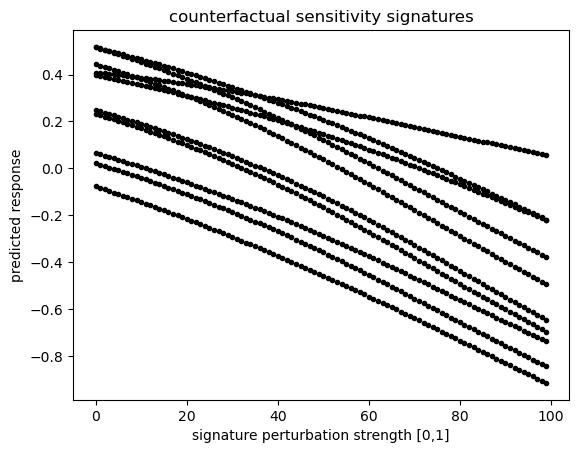

In [87]:
# choose some other random patients 
x_batch = xs[synth_drug[lambda x: (x.inhibitor_1 == xpl_drug) & (x.stag_mut == 1)].sample(30).index.values]

x_sig = torch.tensor(res.perturbation.values, dtype=torch.float32).view(1, -1).cuda()

plt.figure() 

for i in range(10): 
    xxx = x_batch[[i]].expand(100, -1) + x_sig.expand(100, -1)*torch.linspace(0, 1, 100).view(100, 1).cuda() 
    with torch.no_grad(): yhat = model(xxx).detach().cpu().numpy() 

    plt.plot(yhat, 'k.') 

plt.xlabel('signature perturbation strength [0,1]')
plt.ylabel('predicted response')
plt.title('counterfactual sensitivity signatures')

plt.show() 

## Try counterfactuals with drugs, look for combos 

In [88]:
torch.cuda.empty_cache() 

In [89]:
#x_res_batch = xs[synth_drug.sort_values('yhat', ascending=False).head(100).index.values]
from matplotlib.pyplot import xscale


device = 'cuda' if torch.cuda.is_available() else 'cpu'

drug_ixs = torch.tensor([i for i,n in enumerate(data.node_names_dict['input']) if 'DRUG__' in n], dtype=torch.long)

x_drug_prob = torch.zeros(1, drug_ixs.shape[0], device=device, requires_grad=True)  

optim = torch.optim.Adam([x_drug_prob], lr=1e-2) 

batch_size = 32

losses = [] 
for i in range(1000): 
    optim.zero_grad() 
    x_drug = torch.nn.functional.gumbel_softmax(x_drug_prob, dim=-1, hard=False, tau=3)  
    batch_ixs = torch.randint(0, xs.shape[0], (batch_size,))
    xx = xs.clone()[batch_ixs]
    xx[:, drug_ixs] = x_drug
    yhat = model(xx.to(device)) 
    loss = yhat.mean() 
    loss.backward() 
    optim.step() 
    print(i, loss.item(), end='\r') 
    losses.append(loss.item()) 

drug_comb_res = pd.DataFrame({'inhibitor':np.array(data.node_names_dict['input'])[drug_ixs], 'prob':x_drug_prob.softmax(dim=-1).detach().cpu().numpy().flatten()})

In [90]:
drug_comb_res = pd.DataFrame({'inhibitor':np.array(data.node_names_dict['input'])[drug_ixs], 'prob':x_drug_prob.softmax(dim=-1).detach().cpu().numpy().flatten()})
drug_comb_res.sort_values('prob', ascending=False).head(10)

,inhibitor,prob
107,DRUG__selinexor,0.982073
92,DRUG__sns-032 (bms-387032),0.017413
90,DRUG__venetoclax,0.000254
52,DRUG__ink-128,0.000137
48,DRUG__at7519,0.000055
105,DRUG__foretinib (xl880),0.000051
60,DRUG__pi-103,0.000002
21,DRUG__ast-487,0.000002
120,DRUG__otx-015,0.000002
113,DRUG__a-674563,0.000002


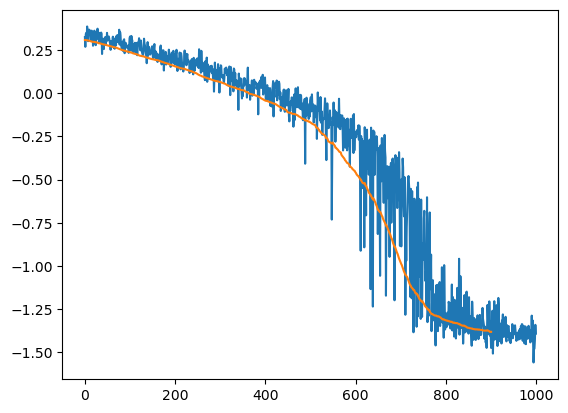

In [91]:
plt.figure() 
plt.plot(losses) 
# running mean 
plt.plot(np.convolve(losses, np.ones(100)/100, mode='valid')) 
plt.show() 

In [92]:
# TODO: filter to high performance drugs 

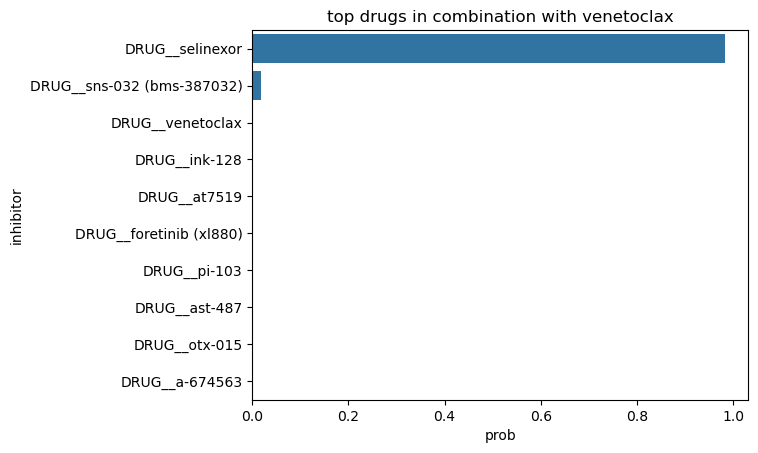

In [93]:
plt.figure() 
sbn.barplot(y='inhibitor', x='prob', orient='h', data=drug_comb_res.sort_values('prob', ascending=False).head(10)) 

plt.title('top drugs in combination with venetoclax')
plt.show() 

In [32]:
#Combination venetoclax and selinexor effective in relapsed refractory multiple myeloma with translocation t(11;14) - https://pmc.ncbi.nlm.nih.gov/articles/PMC9581939/

In [ ]:
# can we explain why drug A + ven is synergistic? 

# compare ven vs ven + drug A , explain difference 